# Process Zillow Home Value Index

This notebook uses the MSA version of the Zillow Home Value Index

Load and transform the Zillow home value index. 

Uses geopy library. Run `%pip install geopy` in the ipynb

- Append latitute, longitude per msa

## Dependencies

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns

In [2]:
zillow_county_url = "https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1769612738"
zillow_msa_url = "https://files.zillowstatic.com/research/public_csvs/zhvi/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1769612738"

county = pd.read_csv(zillow_county_url)
msa = pd.read_csv(zillow_msa_url)
national = msa.loc[msa["RegionName"] == "United States"]
national
county

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2000-01-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,206061.928274,...,867374.483173,862125.892803,857186.525846,853071.199411,851185.234489,851150.211029,853211.151728,855989.594958,859156.857485,862611.160759
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,146029.363629,...,306942.939098,307203.805204,307191.210828,307202.162853,307923.137465,308819.165588,310154.962163,311431.013752,312908.605715,314473.285131
2,1090,2,Harris County,county,TX,TX,"Houston-The Woodlands-Sugar Land, TX",48,201,110474.528025,...,282848.763468,281822.442916,280829.190825,279793.577133,278940.826351,278193.646294,277646.605803,277196.996694,276968.506867,277014.343264
3,2402,3,Maricopa County,county,AZ,AZ,"Phoenix-Mesa-Chandler, AZ",4,13,144631.999729,...,465811.661227,463806.941745,461775.060189,459895.161860,457875.248230,456221.087414,455150.220351,454722.314235,454944.069391,455721.004573
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,213076.247372,...,932883.647593,929748.977359,924962.804975,919764.729427,915420.243489,912024.110958,910182.012610,910150.707429,911142.427963,913282.786768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,846,3206,Banner County,county,NE,NE,"Scottsbluff, NE",31,7,NaN,...,354997.229377,352285.133637,349338.259811,348347.900216,351081.845514,355700.310200,360346.398525,364210.169823,365754.229295,365841.099940
3069,1648,3207,Daggett County,county,UT,UT,NaN,49,9,NaN,...,316420.383867,316173.634522,315385.704830,315058.850151,317232.627396,320315.794992,324699.804734,327599.474415,330192.012641,331301.182709
3070,1432,3208,Thomas County,county,NE,NE,NaN,31,171,NaN,...,184285.924337,184662.538123,184497.932978,183801.949968,181939.499489,180006.028901,178602.909895,177826.264891,175971.906048,174337.233037
3071,2794,3212,McPherson County,county,NE,NE,"North Platte, NE",31,117,NaN,...,352334.720254,351515.627739,348445.898931,345062.898453,342990.696050,343338.517334,345256.394406,349508.717919,353849.248543,358320.396644


In [3]:
# Add the national index to the county level data
df = pd.concat([county, national],sort=False, ignore_index=True)

In [4]:
df.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS', '2000-01-31',
       ...
       '2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30', '2025-07-31',
       '2025-08-31', '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31'],
      dtype='object', length=321)

In [123]:
class ZillowDataCounty():
    DTYPES = {
        'RegionID': 'Int64',
        'SizeRank': 'Int64',
        'RegionName': 'object',
        'RegionType': 'object',
        'StateName': 'object',
        'State': 'object',
        'Metro': 'object',
        'StateCodeFIPS': 'Int64',
        'MunicipalCodeFIPS': 'Int64'
    }
    
    META_DATA_COLS = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
                      'StateName', 'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS',
                      'latitude', 'longitude']
    
    def __init__(self, df):
        self.df = df.astype(self.DTYPES)
        all_columns = self.df.columns.tolist() + [col for col in self.META_DATA_COLS if col not in self.df.columns]
        self.df = self.df.reindex(columns=all_columns)
        
    def fips_time_series(self, fips: tuple = ()):
        """
        Returns DataFrame with one column of time series data
        """
        regional = self.df.loc[(df['StateCodeFIPS'] == fips[0]) & (df['MunicipalCodeFIPS'] == fips[1])]
        
        if regional.empty:
            return pd.DataFrame()
        
        regional_data = regional.loc[:, self.date_cols()].T
        
        region_name = regional['RegionName'].iloc[0]
        new_columns = pd.MultiIndex.from_tuples(
            [(region_name, fips[0], fips[1])],
            names=['Region', 'StateFIPS', 'CountyFIPS']
        )
        
        regional_data.columns = new_columns
        regional_data.index = pd.to_datetime(regional_data.index)
        return regional_data
    
    def normalized_from_date(self, start_date, months_back=0):
        """
        Returns a DataFrame that is scaled to 100 as of the start_date
        """
        start_date = pd.to_datetime(start_date)
        
        
        if months_back > 0:
            window_start_date = start_date - pd.DateOffset(months=months_back)
        else:
            window_start_date = start_date
        
        all_dates = self.date_cols()
        result_dates = [date for date in all_dates if pd.to_datetime(date) >= window_start_date]
        
        if not result_dates:
            return pd.DataFrame()
        ref_col = min(result_dates, key=lambda x: abs(pd.to_datetime(x) - start_date))
        
        result_cols = self.META_DATA_COLS + result_dates        
        normalized_df = self.df[result_cols].copy()
        baseline = normalized_df[ref_col] / 100.0
        normalized_df[result_dates] = normalized_df[result_dates].div(baseline, axis=0)
        return normalized_df

    def change_after_event(self, event_date, fips):
        """
        Returns a DataFrame with the normalized index for a set of region
        1, 2, 3, 6, 12 months after an event data
        """
        norm_df = self.normalized_from_date(event_date, months_back=24)
        country_mask = norm_df["RegionType"] == "country"
        fips_mask = (norm_df['StateCodeFIPS'] == fips[0]) & (norm_df['MunicipalCodeFIPS'] == fips[1])
        norm_df = norm_df[fips_mask | country_mask]
        available_dates = [col for col in norm_df.columns if col not in self.META_DATA_COLS]
        event_date = pd.to_datetime(event_date)
        intervals = list(range(1,13))
        results = norm_df[self.META_DATA_COLS].copy()
        
        for m in intervals:
            plus_date = event_date + pd.DateOffset(months=m)
            closest_date = min(available_dates, key=lambda x: abs(pd.to_datetime(x) - plus_date))
            
            if abs(pd.to_datetime(closest_date) - plus_date).days < 15:
                 results[f'plus_{m}_mon'] = norm_df[closest_date]
            else:
                 results[f'plus_{m}_mon'] = np.nan
            
            minus_date = event_date - pd.DateOffset(months=m)
            closest_minus = min(available_dates, key=lambda x: abs(pd.to_datetime(x) - minus_date))
            if abs(pd.to_datetime(closest_minus) - minus_date).days < 15:
                results[f'minus_{m}_mon'] = norm_df[closest_minus]
            else:
                results[f'minus_{m}_mon'] = np.nan
        
        results.reset_index(inplace=True, drop=True)
        return results

    def latest_date(self):
        return self.date_cols()[-1]

    def date_cols(self):
        dates = [col for col in self.df.columns if col not in self.META_DATA_COLS]
        dates = sorted(dates, key=pd.to_datetime)
        return list(dates)



## Load raw data from Zillow URL

In [124]:
zillow = ZillowDataCounty(df)
zillow.df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2000-01-31,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,latitude,longitude
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,206061.928274,...,857186.525846,853071.199411,851185.234489,851150.211029,853211.151728,855989.594958,859156.857485,862611.160759,NaN,NaN
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,146029.363629,...,307191.210828,307202.162853,307923.137465,308819.165588,310154.962163,311431.013752,312908.605715,314473.285131,NaN,NaN
2,1090,2,Harris County,county,TX,TX,"Houston-The Woodlands-Sugar Land, TX",48,201,110474.528025,...,280829.190825,279793.577133,278940.826351,278193.646294,277646.605803,277196.996694,276968.506867,277014.343264,NaN,NaN
3,2402,3,Maricopa County,county,AZ,AZ,"Phoenix-Mesa-Chandler, AZ",4,13,144631.999729,...,461775.060189,459895.161860,457875.248230,456221.087414,455150.220351,454722.314235,454944.069391,455721.004573,NaN,NaN
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,213076.247372,...,924962.804975,919764.729427,915420.243489,912024.110958,910182.012610,910150.707429,911142.427963,913282.786768,NaN,NaN


In [113]:
latest_month = zillow.latest_date()
assert latest_month == '2025-12-31'
print(f"Latest data is from: {latest_month}")

Latest data is from: 2025-12-31


In [103]:
"""check the data types"""
df = zillow.df

assert df.dtypes['RegionID'] == 'Int64'
assert df.dtypes['SizeRank'] == 'Int64'
assert df.dtypes['RegionName'] == 'object'
assert df.dtypes['RegionType'] == 'object'
assert df.dtypes['StateName'] == 'object'
assert df.dtypes['2025-11-30'] == 'float64'
assert df.dtypes['2000-01-31'] == 'float64'

In [104]:
zillow.fips_time_series((6,37))

Region,Los Angeles County
StateFIPS,6
CountyFIPS,37
2000-01-31,206061.928274
2000-02-29,206294.936055
2000-03-31,207155.147639
2000-04-30,208858.334436
2000-05-31,211024.374136
...,...
2025-08-31,851150.211029
2025-09-30,853211.151728


# Measuring change after a weather event

Assumptions:
If a weather event has a negative effect it is likely in the short term and the prices should revert to the national trend after some amount of time

Both the duration of the decline and the slope of the decline matter, so we want to capture that effect
ChangeIndex = min(SUM(CountyIndex - NationalIndex) for each timeframe 1-N for N in 1-12)

In [139]:
change = zillow.change_after_event("2022-01-31", (6,37))
print(change.columns)
change

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'Metro', 'StateCodeFIPS', 'MunicipalCodeFIPS', 'latitude',
       'longitude', 'plus_1_mon', 'minus_1_mon', 'plus_2_mon', 'minus_2_mon',
       'plus_3_mon', 'minus_3_mon', 'plus_4_mon', 'minus_4_mon', 'plus_5_mon',
       'minus_5_mon', 'plus_6_mon', 'minus_6_mon', 'plus_7_mon', 'minus_7_mon',
       'plus_8_mon', 'minus_8_mon', 'plus_9_mon', 'minus_9_mon', 'plus_10_mon',
       'minus_10_mon', 'plus_11_mon', 'minus_11_mon', 'plus_12_mon',
       'minus_12_mon'],
      dtype='object')


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,latitude,...,plus_8_mon,minus_8_mon,plus_9_mon,minus_9_mon,plus_10_mon,minus_10_mon,plus_11_mon,minus_11_mon,plus_12_mon,minus_12_mon
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,NaN,...,105.536421,91.159114,104.931873,90.048955,104.510764,89.307118,104.163548,89.062621,103.126302,88.453601
1,102001,0,United States,country,NaN,NaN,NaN,<NA>,<NA>,NaN,...,109.357620,91.463360,108.970374,89.976469,108.652426,88.636152,108.363653,87.410642,107.985210,86.236568


In [95]:

lowest = 100
cumulative = 0
for n in range(1,13):
    period = f"plus_{n}_mon"
    delta = change.loc[0 , period ] - change.loc[1 , period ]
    cumulative += delta
    if cumulative < lowest:
        lowest = cumulative
lowest

-22.38928427424682

This metric finds the difference from the county to the national over that timeframe. Some counties were already underperforming the national prior to the storm event. We need to normalize this change for the trend that was already happening before the storm.

Find the average difference between the county and national for the 6 months prior to the event. Reduce the storm event change by this trend rate.





In [96]:
scores = []
cumulative = 0
for n in range(1,13):
    # Calculate the cumulative change 
    period = f"plus_{n}_mon"
    current_period_change = change.loc[0 , period ] - change.loc[1 , period ]
    cumulative += current_period_change
    scores.append(cumulative)
scores

[-0.5525515507649601,
 -1.8010525205731227,
 -3.501946875173772,
 -5.576637049927555,
 -7.950083311286775,
 -10.420845020655506,
 -12.832895364605704,
 -15.076723851589804,
 -17.123672016118178,
 -18.99600016986807,
 -20.692642222057444,
 -22.38928427424682]

In [97]:
adjustments = []
for n in range(1,13):
    # Calculate the pre-event slope
    period = f"minus_{n}_mon"
    current_period_change = change.loc[0 , period ] - change.loc[1 , period ]
    adjustments.append(current_period_change/n)
adjustments

[-1.4210854715202004e-14,
 -7.105427357601002e-15,
 -4.736951571734001e-15,
 -3.552713678800501e-15,
 -2.842170943040401e-15,
 -2.3684757858670005e-15,
 -2.0301221021717147e-15,
 -1.7763568394002505e-15,
 -1.578983857244667e-15,
 -1.4210854715202005e-15,
 -1.2918958832001822e-15,
 -1.1842378929335002e-15]

In [98]:
metric = min(score - adjustment for score, adjustment in zip(scores, adjustments) )
metric

-22.38928427424682

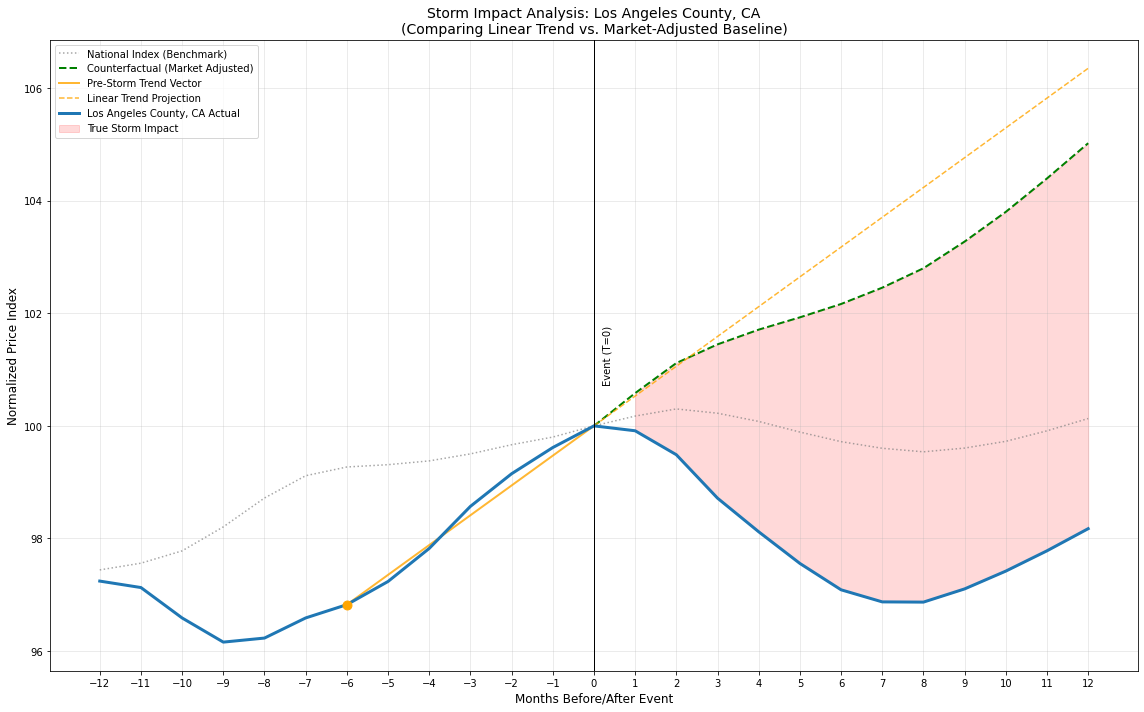

In [141]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.transforms as transforms

def plot_trend_adjusted_impact(change_df, trend_window=6, county_name=None):
    """
    Plots Actual vs. Counterfactual with an extended linear trend line.
    """
    
    # --- 1. SAFE DATA EXTRACTION ---
    try:
        county_row = change_df[change_df['RegionType'] != 'country'].iloc[0]
        national_row = change_df[change_df['RegionType'] == 'country'].iloc[0]
        
        if county_name is None:
            county_name = f"{county_row['RegionName']}, {county_row['State']}"
            
    except IndexError:
        print("Error: Could not find both 'country' and county data rows.")
        return

    # --- 2. BUILD TIME SERIES ---
    months = range(-12, 13) 
    county_vals = []
    national_vals = []
    
    for m in months:
        val_c = np.nan
        val_n = np.nan
        
        if m < 0:
            col = f'minus_{abs(m)}_mon'
            if col in change_df.columns and pd.notna(county_row[col]):
                val_c = county_row[col]
                val_n = national_row[col]     
        elif m == 0:
            val_c = 100.0
            val_n = 100.0
        else:
            col = f'plus_{m}_mon'
            if col in change_df.columns and pd.notna(county_row[col]):
                val_c = county_row[col]
                val_n = national_row[col]

        county_vals.append(val_c)
        national_vals.append(val_n)

    county_vals = np.array(county_vals, dtype=float)
    national_vals = np.array(national_vals, dtype=float)
    months = np.array(months)

    # --- 3. CALCULATE TRENDS ---
    
    trend_col = f'minus_{trend_window}_mon'
    
    # Defaults
    trend_slope_gap = 0     # For Green Line (Relative to Market)
    raw_slope = 0           # For Orange Line (Linear Projection)
    val_county_start = np.nan

    if trend_col in change_df.columns and pd.notna(county_row.get(trend_col)):
        val_county_start = county_row[trend_col]
        val_national_start = national_row[trend_col]
        
        # A. Market-Relative Slope (For Counterfactual)
        gap_start = val_county_start - val_national_start
        # At T=0, gap is 0. Slope = (0 - gap_start) / window
        trend_slope_gap = (0.0 - gap_start) / float(trend_window)

        # B. Raw Linear Slope (For Simple Extrapolation)
        # Slope = (Value_End - Value_Start) / Window
        raw_slope = (100.0 - val_county_start) / float(trend_window)
    else:
        print(f"Warning: Data for -{trend_window} months missing.")

    # Generate Green Counterfactual (Market Adjusted)
    counterfactual_vals = national_vals.copy()
    future_indices = np.where(months > 0)
    expected_gaps = trend_slope_gap * months[future_indices]
    counterfactual_vals[future_indices] = national_vals[future_indices] + expected_gaps

    # Generate Orange Linear Projection (Straight Line)
    # y = mx + b  =>  y = raw_slope * month + 100
    linear_projection_vals = np.full(len(months), np.nan)
    linear_projection_vals[future_indices] = (raw_slope * months[future_indices]) + 100.0

    # --- 4. PLOTTING ---
    
    plt.figure(figsize=(16, 10))
    
    # A. Reference (National)
    plt.plot(months, national_vals, label='National Index (Benchmark)', 
             color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    
    # B. Green Counterfactual (Market Adjusted)
    mask_cf = (months >= 0) & (~np.isnan(counterfactual_vals))
    plt.plot(months[mask_cf], counterfactual_vals[mask_cf], 
             label='Counterfactual (Market Adjusted)', 
             color='green', linestyle='--', linewidth=2)
    
    # C. Orange Trend Lines (The New Request)
    if pd.notna(val_county_start):
        # 1. Solid Line: The actual history used (-Window to 0)
        plt.plot([-trend_window, 0], [val_county_start, 100], 
                 color='orange', linestyle='-', linewidth=2, alpha=0.8,
                 label='Pre-Storm Trend Vector')
        plt.scatter([-trend_window], [val_county_start], color='orange', s=80, zorder=5)

        # 2. Dashed Line: The extension into the future (0 to +12)
        # We only plot this as far as we have data to keep the chart clean
        max_idx = np.where(~np.isnan(county_vals))[0][-1]
        max_month = months[max_idx]
        if max_month > 0:
            plt.plot([0, max_month], [100, 100 + (raw_slope * max_month)], 
                     color='orange', linestyle='--', linewidth=1.5, alpha=0.8,
                     label='Linear Trend Projection')

    # D. Actual Data
    mask_act = ~np.isnan(county_vals)
    plt.plot(months[mask_act], county_vals[mask_act], label=f'{county_name} Actual', 
             color='#1f77b4', linewidth=3)

    # E. Shade Impact
    mask_fill = (months > 0) & (~np.isnan(county_vals)) & (~np.isnan(counterfactual_vals))
    if np.any(mask_fill):
        plt.fill_between(months[mask_fill], 
                         counterfactual_vals[mask_fill], 
                         county_vals[mask_fill], 
                         color='red', alpha=0.15, label='True Storm Impact')

    # Formatting
    plt.axvline(x=0, color='black', linewidth=1)
    trans = transforms.blended_transform_factory(plt.gca().transData, plt.gca().transAxes)
    plt.text(0.2, 0.5, 'Event (T=0)', rotation=90, 
             verticalalignment='center', transform=trans, color='black')
    
    plt.title(f'Storm Impact Analysis: {county_name}\n(Comparing Linear Trend vs. Market-Adjusted Baseline)', fontsize=14)
    plt.xlabel('Months Before/After Event', fontsize=12)
    plt.ylabel('Normalized Price Index', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(np.arange(-12, 13, 1))
    
    plt.tight_layout()
    plt.show()
    
change = zillow.change_after_event("2024-12-31", (6,37)) 
plot_trend_adjusted_impact(change, trend_window=6)

## Seasonality

The orange trend line could be just the effect of seasonality

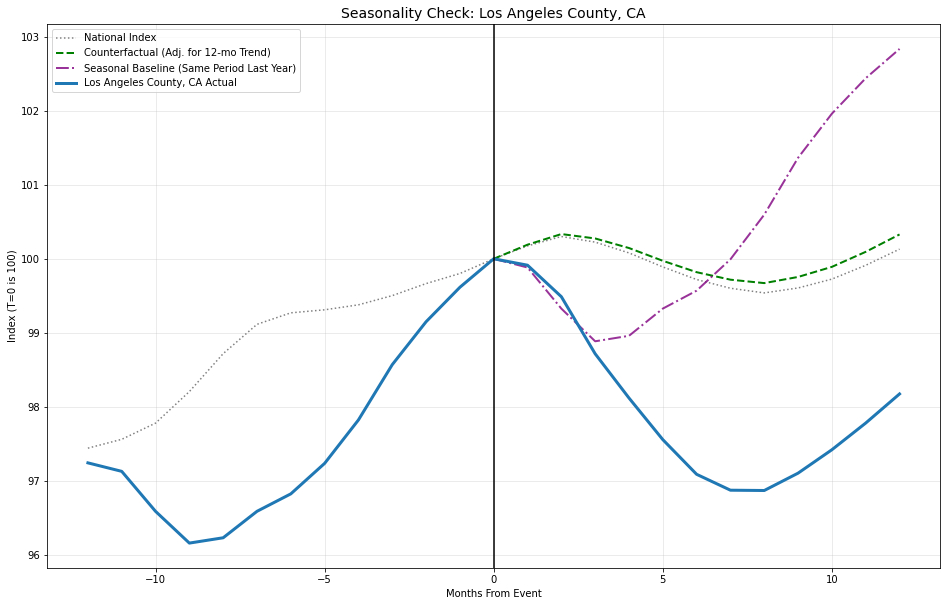

In [134]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.transforms as transforms

def plot_seasonality_check(change_df, trend_window=12, county_name=None):
    """
    Plots Actual vs. Counterfactual vs. SEASONAL EXPECTATION.
    """
    
    # --- 1. SAFE DATA EXTRACTION ---
    try:
        county_row = change_df[change_df['RegionType'] != 'country'].iloc[0]
        national_row = change_df[change_df['RegionType'] == 'country'].iloc[0]
        if county_name is None:
            county_name = f"{county_row['RegionName']}, {county_row['State']}"
    except IndexError:
        print("Error: Could not find rows.")
        return

    # --- 2. BUILD DATA ---
    months = range(-12, 13) 
    county_vals = []
    national_vals = []
    
    # Helper to safely get value or NaN
    def get_val(row, m_idx):
        if m_idx < 0: col = f'minus_{abs(m_idx)}_mon'
        elif m_idx == 0: return 100.0
        else: col = f'plus_{m_idx}_mon'
        
        if col in change_df.columns and pd.notna(row.get(col)):
            return row[col]
        return np.nan

    for m in months:
        county_vals.append(get_val(county_row, m))
        national_vals.append(get_val(national_row, m))

    county_vals = np.array(county_vals, dtype=float)
    national_vals = np.array(national_vals, dtype=float)
    months = np.array(months)

    # --- 3. CALCULATE "SAME PERIOD LAST YEAR" (SPLY) PROJECTION ---
    # We want to see how the market moved exactly 12 months ago.
    # To predict T+1, we look at the movement from T-12 to T-11.
    
    seasonal_vals = np.full(len(months), np.nan)
    
    # Start the seasonal line at 100 (T=0)
    seasonal_vals[months == 0] = 100.0
    
    # Calculate the shape of the PREVIOUS year (T-12 to T0)
    # We need the history from -12 to 0 to project 0 to +12
    try:
        # Base value at T-12 (The start of the comparison period)
        base_minus_12 = get_val(county_row, -12)
        
        if pd.notna(base_minus_12):
            # Calculate the cumulative growth curve of the previous year
            # Curve_shape = Value_at_m / Value_at_minus_12
            
            # We project this shape forward. 
            # For month +1, we want the growth that happened at month -11 relative to -12
            for i in range(1, 13):
                # The proxy month is T - 12 + i
                # e.g. For T+1, we look at T-11. For T+2, look at T-10.
                past_val = get_val(county_row, -12 + i)
                
                if pd.notna(past_val):
                    # Growth factor since start of last year's window
                    growth_factor = past_val / base_minus_12
                    
                    # Apply that growth factor to our current T=0 start (100)
                    seasonal_vals[months == i] = 100.0 * growth_factor
    except Exception as e:
        print(f"Could not calculate seasonal projection: {e}")

    # --- 4. CALCULATE MARKET-ADJUSTED COUNTERFACTUAL ---
    # Using 12-month window by default to smooth seasonality
    trend_col = f'minus_{trend_window}_mon'
    val_start = county_row.get(trend_col, np.nan)
    val_nat_start = national_row.get(trend_col, np.nan)
    
    counterfactual_vals = national_vals.copy()
    
    if pd.notna(val_start) and pd.notna(val_nat_start):
        gap_start = val_start - val_nat_start
        slope = (0.0 - gap_start) / float(trend_window)
        
        future_idx = np.where(months > 0)
        expected_gaps = slope * months[future_idx]
        counterfactual_vals[future_idx] = national_vals[future_idx] + expected_gaps

    # --- 5. PLOTTING ---
    plt.figure(figsize=(16, 10))
    
    # A. National Benchmark
    plt.plot(months, national_vals, color='gray', linestyle=':', label='National Index')
    
    # B. Market-Adjusted (Green)
    mask_cf = (months >= 0) & (~np.isnan(counterfactual_vals))
    plt.plot(months[mask_cf], counterfactual_vals[mask_cf], 
             color='green', linestyle='--', linewidth=2, 
             label=f'Counterfactual (Adj. for {trend_window}-mo Trend)')

    # C. SPLY Seasonal Projection (Purple) - NEW!
    mask_sea = (months >= 0) & (~np.isnan(seasonal_vals))
    plt.plot(months[mask_sea], seasonal_vals[mask_sea], 
             color='purple', linestyle='-.', linewidth=2, alpha=0.8,
             label='Seasonal Baseline (Same Period Last Year)')

    # D. Actual
    mask_act = ~np.isnan(county_vals)
    plt.plot(months[mask_act], county_vals[mask_act], 
             color='#1f77b4', linewidth=3, label=f'{county_name} Actual')

    # Formatting
    plt.axvline(x=0, color='black')
    plt.title(f'Seasonality Check: {county_name}', fontsize=14)
    plt.xlabel('Months From Event')
    plt.ylabel('Index (T=0 is 100)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()
    
plot_seasonality_check(change, trend_window=12)

## Regression Implications

In a regression model we want to control for both seasonal effects and national trends.

We want to consider adjusments for both

$Composite = NationalTrend + SeasonalChange$

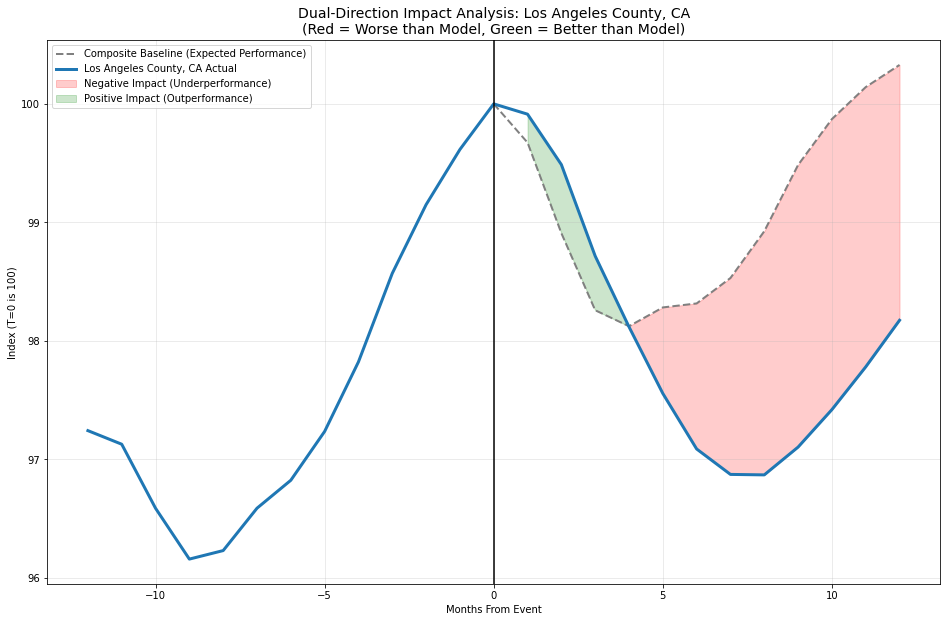

In [137]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.transforms as transforms

def plot_dual_impact_analysis(change_df, trend_window=12, county_name=None):
    """
    Plots the Composite Baseline and shades POSITIVE (Green) vs NEGATIVE (Red) impacts.
    """
    
    # --- 1. SAFE DATA EXTRACTION ---
    try:
        county_row = change_df[change_df['RegionType'] != 'country'].iloc[0]
        national_row = change_df[change_df['RegionType'] == 'country'].iloc[0]
        if county_name is None:
            county_name = f"{county_row['RegionName']}, {county_row['State']}"
    except IndexError:
        print("Error: Could not find rows.")
        return

    months = np.array(range(-12, 13))
    
    def get_series(row):
        vals = []
        for m in months:
            if m < 0: col = f'minus_{abs(m)}_mon'
            elif m == 0: col = 'ZERO'
            else: col = f'plus_{m}_mon'
            
            if m == 0: vals.append(100.0)
            elif col in change_df.columns and pd.notna(row.get(col)): vals.append(row[col])
            else: vals.append(np.nan)
        return np.array(vals, dtype=float)

    county_vals = get_series(county_row)
    national_vals = get_series(national_row)

    # --- 2. CALCULATE COMPOSITE BASELINE ---
    
    # A. National Trend
    trend_col = f'minus_{trend_window}_mon'
    val_start = county_row.get(trend_col, np.nan)
    val_nat_start = national_row.get(trend_col, np.nan)
    
    green_line = national_vals.copy()
    if pd.notna(val_start) and pd.notna(val_nat_start):
        gap_start = val_start - val_nat_start
        slope_adj = (0.0 - gap_start) / float(trend_window)
        future_idx = np.where(months > 0)
        green_line[future_idx] = national_vals[future_idx] + (slope_adj * months[future_idx])

    # B. Seasonal Shape (SPLY)
    purple_line = np.full(len(months), np.nan)
    purple_line[months == 0] = 100.0
    try:
        base_minus_12 = get_series(county_row)[0] 
        if pd.notna(base_minus_12):
            for i in range(1, 13):
                past_val = get_series(county_row)[i] 
                if pd.notna(past_val):
                    growth = past_val / base_minus_12
                    purple_line[months == i] = 100.0 * growth
    except: pass

    # C. Composite (Gold Line)
    gold_line = purple_line.copy()
    mask_purple = (months > 0) & (~np.isnan(purple_line))
    mask_green = (months > 0) & (~np.isnan(green_line))
    common_indices = np.where(mask_purple & mask_green)[0]
    
    if len(common_indices) > 0:
        last_idx = common_indices[-1]
        last_month = months[last_idx]
        slope_purple = (purple_line[last_idx] - 100.0) / last_month
        slope_green = (green_line[last_idx] - 100.0) / last_month
        slope_correction = slope_green - slope_purple
        future_indices = np.where(months > 0)
        gold_line[future_indices] = purple_line[future_indices] + (slope_correction * months[future_indices])

    # --- 3. PLOTTING ---
    plt.figure(figsize=(16, 10))
    
    # Plot Composite Baseline
    mask_gold = (months >= 0) & (~np.isnan(gold_line))
    plt.plot(months[mask_gold], gold_line[mask_gold], 
             color='gray', linestyle='--', linewidth=2,  
             label='Composite Baseline (Expected Performance)')

    # Plot Actual Data
    mask_act = ~np.isnan(county_vals)
    plt.plot(months[mask_act], county_vals[mask_act], 
             color='#1f77b4', linewidth=3, label=f'{county_name} Actual')

    # --- DUAL COLOR SHADING LOGIC ---
    mask_fill = (months > 0) & (~np.isnan(county_vals)) & (~np.isnan(gold_line))
    
    if np.any(mask_fill):
        # 1. Shade Red where Actual < Composite
        plt.fill_between(months[mask_fill], 
                         gold_line[mask_fill], 
                         county_vals[mask_fill], 
                         where=(county_vals[mask_fill] < gold_line[mask_fill]),
                         interpolate=True, # Ensures colors meet perfectly
                         color='red', alpha=0.2, label='Negative Impact (Underperformance)')

        # 2. Shade Green where Actual > Composite
        plt.fill_between(months[mask_fill], 
                         gold_line[mask_fill], 
                         county_vals[mask_fill], 
                         where=(county_vals[mask_fill] > gold_line[mask_fill]),
                         interpolate=True,
                         color='green', alpha=0.2, label='Positive Impact (Outperformance)')

    # Formatting
    plt.axvline(x=0, color='black')
    plt.title(f'Dual-Direction Impact Analysis: {county_name}\n(Red = Worse than Model, Green = Better than Model)', fontsize=14)
    plt.xlabel('Months From Event')
    plt.ylabel('Index (T=0 is 100)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_dual_impact_analysis(change)